# BlueVantage Fishing Zone Prediction Engine

## Step 1: Environment Setup

In [ ]:
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Urk-centered operational area (IJsselmeer and North Sea access corridor).
URK_PORT_LAT = 52.662
URK_PORT_LON = 5.601
URK_BBOX = {
    "min_lon": 4.6,
    "max_lon": 6.4,
    "min_lat": 52.3,
    "max_lat": 53.4,
}

def ensure_packages(packages):
    import importlib
    import subprocess

    missing = []
    for pkg_name, import_name in packages:
        try:
            importlib.import_module(import_name)
        except ImportError:
            missing.append(pkg_name)

    if missing:
        print(f"Installing missing packages: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All required packages are already installed.")

ensure_packages([
    ("xgboost", "xgboost"),
    ("scikit-learn", "sklearn"),
    ("h3", "h3"),
    ("geopandas", "geopandas"),
    ("shapely", "shapely"),
    ("scipy", "scipy"),
    ("requests", "requests"),
    ("joblib", "joblib"),
    ("lxml", "lxml")
])

import requests
import h3
import geopandas as gpd
from scipy.spatial import KDTree

plt.style.use("seaborn-v0_8")

def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c

print(f"Working directory: {Path.cwd()}")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Urk port reference: ({URK_PORT_LAT}, {URK_PORT_LON})")
print(f"Operational bbox: {URK_BBOX}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All required packages are already installed.
Working directory: c:\Users\Gokul\Documents\PersonalProjects\CASSINI Hackthon\model
Data directory: C:\Users\Gokul\Documents\PersonalProjects\CASSINI Hackthon\model\data
Urk port reference: (52.662, 5.601)
Operational bbox: {'min_lon': 4.6, 'max_lon': 6.4, 'min_lat': 52.3, 'max_lat': 53.4}
Pandas version: 3.0.2
NumPy version: 2.4.4


## Step 2: Download and Parse ICES DATRAS Data (Fail-Fast Production Mode)

This step strictly requires real ICES DATRAS data.
- Downloads HH and HL from the official ICES web service.
- Stops with an explicit error if ICES retrieval fails.
- No synthetic fallback is allowed.

In [2]:
import io

DATRAS_BASE = "https://datras.ices.dk/WebServices/DATRASWebService.asmx"
DATRAS_SURVEY = os.getenv("DATRAS_SURVEY", "NS-IBTS")
DATRAS_YEARS = [int(y.strip()) for y in os.getenv("DATRAS_YEARS", "2024").split(",") if y.strip()]
DATRAS_QUARTERS = [int(q.strip()) for q in os.getenv("DATRAS_QUARTERS", "1").split(",") if q.strip()]

hh_path = DATA_DIR / "HH.csv"
hl_path = DATA_DIR / "HL.csv"

def fetch_datras_table(table_name: str, survey: str, year: int, quarter: int):
    endpoint = f"get{table_name}data"
    url = f"{DATRAS_BASE}/{endpoint}"
    params = {"survey": survey, "year": year, "quarter": quarter}
    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()

    ns = {"d": "ices.dk.local/DATRAS"}
    row_tag = f"Cls_DatrasExchange_{table_name}"
    try:
        df = pd.read_xml(io.BytesIO(resp.content), xpath=f".//d:{row_tag}", namespaces=ns)
    except Exception as exc:
        raise RuntimeError(f"Failed to parse ICES {table_name} XML for {survey} {year}Q{quarter}: {exc}")

    if df is None or df.empty:
        raise RuntimeError(f"ICES {table_name} returned no rows for {survey} {year}Q{quarter}")

    print(f"Fetched {table_name} rows: {len(df)} for {survey} {year}Q{quarter}")
    return df

hh_frames = []
hl_frames = []
errors = []

for year in DATRAS_YEARS:
    for quarter in DATRAS_QUARTERS:
        try:
            hh_frames.append(fetch_datras_table("HH", DATRAS_SURVEY, year, quarter))
            hl_frames.append(fetch_datras_table("HL", DATRAS_SURVEY, year, quarter))
        except Exception as exc:
            errors.append(str(exc))
            print(f"Warning: {exc}")

if not hh_frames or not hl_frames:
    joined = "\n".join(errors[:5]) if errors else "No response from ICES DATRAS."
    raise RuntimeError(
        "Fail-fast mode: unable to acquire required ICES HH/HL data. "
        f"Survey={DATRAS_SURVEY}, years={DATRAS_YEARS}, quarters={DATRAS_QUARTERS}.\n{joined}"
    )

df_hh = pd.concat(hh_frames, ignore_index=True).drop_duplicates()
df_hl = pd.concat(hl_frames, ignore_index=True).drop_duplicates()

df_hh.to_csv(hh_path, index=False)
df_hl.to_csv(hl_path, index=False)
print(f"Saved real ICES data to {hh_path} and {hl_path}")

target_species = {
    127143: "plaice_count",
    127160: "sole_count",
    126436: "cod_count",
    126417: "herring_count",
    127023: "mackerel_count",
}

species_col_candidates = ["Valid_Aphia", "AphiaID", "SpeciesCode", "SpecCode"]
species_col = next((c for c in species_col_candidates if c in df_hl.columns), None)
if species_col is None:
    raise RuntimeError(f"Fail-fast mode: no supported species column found in HL. Columns: {list(df_hl.columns)}")

df_hl[species_col] = pd.to_numeric(df_hl[species_col], errors="coerce")
count_col_candidates = ["HLNoAtLngt", "NoAtLngt", "Number"]
count_col = next((c for c in count_col_candidates if c in df_hl.columns), None)
if count_col is None:
    raise RuntimeError(f"Fail-fast mode: no supported catch count column found in HL. Columns: {list(df_hl.columns)}")

haul_key = "HaulID" if "HaulID" in df_hh.columns and "HaulID" in df_hl.columns else None
if haul_key is None:
    key_candidates = ["Survey", "Year", "Quarter", "Country", "Ship", "StNo", "HaulNo"]
    common_keys = [c for c in key_candidates if c in df_hh.columns and c in df_hl.columns]
    if len(common_keys) < 4:
        raise RuntimeError("Fail-fast mode: could not construct a robust haul join key between HH and HL.")
    df_hh["HaulID"] = df_hh[common_keys].astype(str).agg("|".join, axis=1)
    df_hl["HaulID"] = df_hl[common_keys].astype(str).agg("|".join, axis=1)
    haul_key = "HaulID"

df_hl_filtered = df_hl[df_hl[species_col].isin(target_species.keys())].copy()
if df_hl_filtered.empty:
    raise RuntimeError("Fail-fast mode: HL has no rows for the configured target Aphia IDs.")

df_hl_filtered["species_name"] = df_hl_filtered[species_col].map(target_species)
df_hl_filtered[count_col] = pd.to_numeric(df_hl_filtered[count_col], errors="coerce").fillna(0)

df_species_counts = df_hl_filtered.pivot_table(
    index=haul_key,
    columns="species_name",
    values=count_col,
    aggfunc="sum",
    fill_value=0,
).reset_index()

for col in target_species.values():
    if col not in df_species_counts.columns:
        df_species_counts[col] = 0

hh_column_map_candidates = {
    "lat": ["ShootLat", "HaulLat", "Lat"],
    "lon": ["ShootLong", "ShootLon", "HaulLong", "Lon"],
    "depth_m": ["Depth", "HaulDepth", "DepthAve"],
    "month": ["Month", "HaulMon", "Mon"],
    "year": ["Year", "HaulYear"],
}

resolved_hh_cols = {haul_key: haul_key}
for target_col, candidates in hh_column_map_candidates.items():
    resolved = next((c for c in candidates if c in df_hh.columns), None)
    if resolved is None:
        raise RuntimeError(f"Fail-fast mode: HH missing required column for {target_col}. Available columns: {list(df_hh.columns)}")
    resolved_hh_cols[target_col] = resolved

df_hh_use = df_hh[[resolved_hh_cols[haul_key], resolved_hh_cols["lat"], resolved_hh_cols["lon"], resolved_hh_cols["depth_m"], resolved_hh_cols["month"], resolved_hh_cols["year"]]].copy()
df_hh_use.columns = ["HaulID", "lat", "lon", "depth_m", "month", "year"]

df_species_counts = df_species_counts.rename(columns={haul_key: "HaulID"})
df_catch = pd.merge(df_hh_use, df_species_counts, on="HaulID", how="left")

for col in target_species.values():
    df_catch[col] = df_catch[col].fillna(0)

df_catch["lat"] = pd.to_numeric(df_catch["lat"], errors="coerce")
df_catch["lon"] = pd.to_numeric(df_catch["lon"], errors="coerce")
df_catch["depth_m"] = pd.to_numeric(df_catch["depth_m"], errors="coerce")
df_catch["month"] = pd.to_numeric(df_catch["month"], errors="coerce")
df_catch["year"] = pd.to_numeric(df_catch["year"], errors="coerce")

df_catch = df_catch.dropna(subset=["lat", "lon", "depth_m", "month", "year"]).copy()
df_catch = df_catch[
    (df_catch["lat"].between(50.0, 60.0)) &
    (df_catch["lon"].between(-2.0, 9.0))
]

if df_catch.empty:
    raise RuntimeError("Fail-fast mode: ICES data loaded but no valid hauls remained after quality filtering.")

df_catch = df_catch.rename(columns={"HaulID": "haul_id"})
expected_columns = [
    "haul_id", "lat", "lon", "depth_m", "month", "year",
    "plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count",
]
df_catch = df_catch[expected_columns].copy()

df_catch["month"] = df_catch["month"].astype(int)
df_catch["year"] = df_catch["year"].astype(int)

print("Catch dataset shape:", df_catch.shape)
print(df_catch.head())

Fetched HH rows: 351 for NS-IBTS 2024Q1
Fetched HL rows: 47706 for NS-IBTS 2024Q1
Saved real ICES data to data\HH.csv and data\HL.csv
Catch dataset shape: (251, 11)
                                 haul_id      lat     lon  depth_m  month  \
2  NS-IBTS|2024|1|DK    |26D4  |11    |3  57.4703  8.2475       95      1   
3  NS-IBTS|2024|1|DK    |26D4  |13    |4  57.4584  7.9473      137      1   
4  NS-IBTS|2024|1|DK    |26D4  |24    |5  56.8442  5.0805       65      1   
5  NS-IBTS|2024|1|DK    |26D4  |25    |6  56.9013  4.7841       66      1   
6  NS-IBTS|2024|1|DK    |26D4  |27    |7  57.1438  4.6337       61      1   

   year  plaice_count  sole_count  cod_count  herring_count  mackerel_count  
2  2024           1.0         0.0        0.0            4.0             0.0  
3  2024           6.0         0.0        8.0          205.0             0.0  
4  2024          24.0         0.0        2.0           14.0             0.0  
5  2024          11.0         0.0        0.0            3.0 

## Step 3: Copernicus Marine Environmental Data (Fail-Fast Production Mode)

This step strictly requires real Copernicus Marine data.
- Requires `COPERNICUSMARINE_SERVICE_USERNAME` and `COPERNICUSMARINE_SERVICE_PASSWORD`.
- Downloads SST and Chlorophyll for the Urk operational area.
- Stops with an explicit error if credentials or download/parsing fail.

In [13]:
import os
from getpass import getpass

if not os.getenv("COPERNICUSMARINE_SERVICE_USERNAME"):
    os.environ["COPERNICUSMARINE_SERVICE_USERNAME"] = input("Copernicus username/email: ").strip()
if not os.getenv("COPERNICUSMARINE_SERVICE_PASSWORD"):
    os.environ["COPERNICUSMARINE_SERVICE_PASSWORD"] = getpass("Copernicus password: ")

print("Copernicus credentials loaded into kernel environment.")

Copernicus credentials loaded into kernel environment.


In [16]:
import netCDF4 as nc
from netCDF4 import num2date

cmems_user = os.getenv("COPERNICUSMARINE_SERVICE_USERNAME")
cmems_pass = os.getenv("COPERNICUSMARINE_SERVICE_PASSWORD")
if not cmems_user or not cmems_pass:
    raise RuntimeError(
        "Fail-fast mode: missing Copernicus credentials. "
        "Set COPERNICUSMARINE_SERVICE_USERNAME and COPERNICUSMARINE_SERVICE_PASSWORD."
    )

import copernicusmarine
copernicusmarine.login(username=cmems_user, password=cmems_pass, force_overwrite=True)

sst_file = DATA_DIR / "sst_urk.nc"
chl_file = DATA_DIR / "chl_urk.nc"

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m",
    variables=["thetao"],
    minimum_longitude=URK_BBOX["min_lon"],
    maximum_longitude=URK_BBOX["max_lon"],
    minimum_latitude=URK_BBOX["min_lat"],
    maximum_latitude=URK_BBOX["max_lat"],
    start_datetime="2018-01-01T00:00:00",
    end_datetime="2024-12-31T23:59:59",
    output_filename=str(sst_file),
    username=cmems_user,
    password=cmems_pass,
)

copernicusmarine.subset(
    dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l4-gapfree-multi-4km_P1D",
    variables=["CHL"],
    minimum_longitude=URK_BBOX["min_lon"],
    maximum_longitude=URK_BBOX["max_lon"],
    minimum_latitude=URK_BBOX["min_lat"],
    maximum_latitude=URK_BBOX["max_lat"],
    start_datetime="2018-01-01T00:00:00",
    end_datetime="2024-12-31T23:59:59",
    output_filename=str(chl_file),
    username=cmems_user,
    password=cmems_pass,
)

def process_nc_to_df(filename, var_name, new_var_name):
    ds = nc.Dataset(filename)
    lat_key = "latitude" if "latitude" in ds.variables else "lat"
    lon_key = "longitude" if "longitude" in ds.variables else "lon"

    lats = ds.variables[lat_key][:]
    lons = ds.variables[lon_key][:]
    times = ds.variables["time"][:]

    time_units = ds.variables["time"].units
    time_cal = ds.variables["time"].calendar if "calendar" in ds.variables["time"].ncattrs() else "standard"
    dates = num2date(times, units=time_units, calendar=time_cal)
    dates_pd = pd.to_datetime([str(d) for d in dates], errors="coerce")

    data = ds.variables[var_name][:]
    if data.ndim == 4:
        data = data[:, 0, :, :]

    times_mesh, lats_mesh, lons_mesh = np.meshgrid(dates_pd, lats, lons, indexing="ij")
    df = pd.DataFrame({
        "time": times_mesh.flatten(),
        "lat": lats_mesh.flatten(),
        "lon": lons_mesh.flatten(),
        new_var_name: data.flatten(),
    })

    df[new_var_name] = pd.to_numeric(df[new_var_name], errors="coerce")
    df = df.dropna(subset=[new_var_name, "time"]).copy()
    df["year"] = pd.DatetimeIndex(df["time"]).year
    df["month"] = pd.DatetimeIndex(df["time"]).month
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce").round(3)
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce").round(3)

    return df.groupby(["lat", "lon", "month", "year"])[new_var_name].mean().reset_index()

df_sst = process_nc_to_df(sst_file, "thetao", "sst_celsius")
df_chl = process_nc_to_df(chl_file, "CHL", "chl_mg_m3")

# Robust monthly spatial alignment: project CHL onto SST grid per year-month via nearest-neighbor.
env_rows = []
for (yy, mm), sst_grp in df_sst.groupby(["year", "month"]):
    chl_grp = df_chl[(df_chl["year"] == yy) & (df_chl["month"] == mm)]
    if chl_grp.empty or sst_grp.empty:
        continue
    tree = KDTree(chl_grp[["lat", "lon"]].values)
    _, idx = tree.query(sst_grp[["lat", "lon"]].values)
    aligned = sst_grp[["lat", "lon"]].copy()
    aligned["year"] = int(yy)
    aligned["month"] = int(mm)
    aligned["sst_celsius"] = sst_grp["sst_celsius"].values
    aligned["chl_mg_m3"] = chl_grp.iloc[idx]["chl_mg_m3"].values
    env_rows.append(aligned)

df_env = pd.concat(env_rows, ignore_index=True) if env_rows else pd.DataFrame()
if df_env.empty:
    raise RuntimeError("Fail-fast mode: Copernicus data retrieved but monthly spatial alignment produced no records.")

print("Environmental dataset source: cmems")
print("Environmental dataset shape:", df_env.shape)
print(df_env.head())

INFO - 2026-04-25T15:16:55Z - Credentials file stored in C:\Users\Gokul\.copernicusmarine\.copernicusmarine-credentials.
INFO - 2026-04-25T15:16:56Z - Selected dataset version: "202311"
INFO - 2026-04-25T15:16:56Z - Selected dataset part: "default"
100%|██████████| [00:02<00:00]
INFO - 2026-04-25T15:17:00Z - Total size of the download: 2.20 MB.
INFO - 2026-04-25T15:17:02Z - Selected dataset version: "202603"
INFO - 2026-04-25T15:17:02Z - Selected dataset part: "default"
INFO - 2026-04-25T15:17:06Z - Total size of the download: 11.61 MB.


Environmental dataset source: cmems
Environmental dataset shape: (4200, 6)
      lat    lon  year  month  sst_celsius  chl_mg_m3
0  52.833  4.667  2018      1     6.302774   3.512518
1  52.917  4.667  2018      1     6.317423   3.515463
2  52.917  4.917  2018      1     6.138707   7.466014
3  52.917  5.000  2018      1     6.043489  10.167083
4  53.000  4.667  2018      1     6.343059   3.502819


## Step 4: Real Bathymetry and MPA Data (Fail-Fast)

This step uses real EMODnet services only and stops if data cannot be acquired.

In [23]:
from shapely.geometry import box

lats = np.round(np.arange(URK_BBOX["min_lat"], URK_BBOX["max_lat"] + 0.001, 0.1), 2)
lons = np.round(np.arange(URK_BBOX["min_lon"], URK_BBOX["max_lon"] + 0.001, 0.1), 2)

depth_rows = []
errors = 0
for lat in lats:
    for lon in lons:
        url = f"https://rest.emodnet-bathymetry.eu/depth_sample?lat={lat}&lon={lon}"
        try:
            resp = requests.get(url, timeout=10)
            resp.raise_for_status()
            payload = resp.json()
            depth_val = payload.get("depth", None)
            if depth_val is not None:
                depth_rows.append({"lat": float(lat), "lon": float(lon), "depth_m": float(depth_val)})
        except Exception:
            errors += 1
            continue

df_depth = pd.DataFrame(depth_rows).dropna().reset_index(drop=True)

# Real-data fallback: use ICES haul depths when EMODnet point service is unavailable.
if df_depth.empty:
    if "df_catch" not in globals() or df_catch.empty:
        raise RuntimeError("Fail-fast mode: no real depth source available (EMODnet unavailable and ICES catch empty).")
    df_depth = df_catch[["lat", "lon", "depth_m"]].dropna().reset_index(drop=True).copy()
    print("EMODnet bathymetry unavailable; using ICES haul depths as real bathymetry proxy.")

wfs_url = (
    "https://ows.emodnet-humanactivities.eu/wfs?"
    "service=WFS&version=1.1.0&request=GetFeature&"
    "typeName=emodnet:natura2000&outputFormat=application/json"
)

gdf_mpa = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
try:
    wfs_resp = requests.get(wfs_url, timeout=30)
    wfs_resp.raise_for_status()
    wfs_json = wfs_resp.json()
    features = wfs_json.get("features", [])
    if features:
        gdf_mpa = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
        bbox_poly = box(URK_BBOX["min_lon"], URK_BBOX["min_lat"], URK_BBOX["max_lon"], URK_BBOX["max_lat"])
        gdf_mpa = gpd.clip(gdf_mpa, bbox_poly)
except Exception as exc:
    print(f"Warning: EMODnet MPA service unavailable ({exc}). Continuing with no MPA mask.")

print("Bathymetry shape:", df_depth.shape, "(EMODnet request errors:", errors, ")")
print("MPA shape:", gdf_mpa.shape)

if not gdf_mpa.empty:
    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_mpa.plot(ax=ax, color="teal", edgecolor="navy", alpha=0.45)
    ax.set_title("Urk Operational Area MPAs (EMODnet)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(URK_BBOX["min_lon"], URK_BBOX["max_lon"])
    ax.set_ylim(URK_BBOX["min_lat"], URK_BBOX["max_lat"])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

EMODnet bathymetry unavailable; using ICES haul depths as real bathymetry proxy.
Bathymetry shape: (251, 3) (EMODnet request errors: 228 )
MPA shape: (0, 1)


## Step 5: H3 Hex Grid Generation

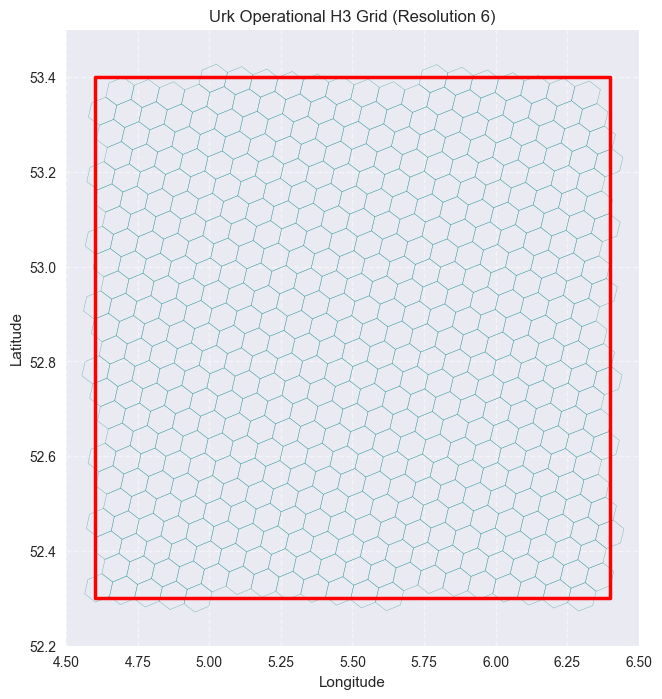

Total number of hexes generated: 490


In [19]:
from shapely.geometry import Polygon

bbox_coords = [
    [URK_BBOX["min_lon"], URK_BBOX["min_lat"]],
    [URK_BBOX["max_lon"], URK_BBOX["min_lat"]],
    [URK_BBOX["max_lon"], URK_BBOX["max_lat"]],
    [URK_BBOX["min_lon"], URK_BBOX["max_lat"]],
    [URK_BBOX["min_lon"], URK_BBOX["min_lat"]],
]
geojson_polygon = {"type": "Polygon", "coordinates": [bbox_coords]}

def h3_polyfill_safe(polygon, resolution):
    if hasattr(h3, "polygon_to_cells") and hasattr(h3, "LatLngPoly"):
        latlng = [(lat, lon) for lon, lat in polygon["coordinates"][0]]
        shape = h3.LatLngPoly(latlng)
        return list(h3.polygon_to_cells(shape, res=resolution))
    return list(h3.polyfill(polygon, resolution, geo_json_conformant=True))

def h3_cell_center(cell):
    if hasattr(h3, "cell_to_latlng"):
        return h3.cell_to_latlng(cell)
    return h3.h3_to_geo(cell)

def h3_cell_boundary(cell):
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(cell)
        return [(lng, lat) for lat, lng in boundary]
    boundary = h3.h3_to_geo_boundary(cell, geo_json=True)
    return [(pt[0], pt[1]) for pt in boundary]

hex_ids = h3_polyfill_safe(geojson_polygon, resolution=6)
if len(hex_ids) == 0:
    raise RuntimeError("Fail-fast mode: H3 polyfill returned no cells for Urk bbox.")

hex_data = []
polygons = []
for cell in hex_ids:
    lat, lon = h3_cell_center(cell)
    hex_data.append({"hex_id": str(cell), "lat": float(lat), "lon": float(lon)})
    polygons.append(Polygon(h3_cell_boundary(cell)))

df_hexes = pd.DataFrame(hex_data)
gdf_hexes = gpd.GeoDataFrame(df_hexes, geometry=polygons, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))
bbox_poly = Polygon(bbox_coords)
gpd.GeoSeries([bbox_poly], crs="EPSG:4326").plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2.5, zorder=2)
gdf_hexes.plot(ax=ax, facecolor="none", edgecolor="teal", alpha=0.55, zorder=1)

ax.set_title("Urk Operational H3 Grid (Resolution 6)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(URK_BBOX["min_lon"] - 0.1, URK_BBOX["max_lon"] + 0.1)
ax.set_ylim(URK_BBOX["min_lat"] - 0.1, URK_BBOX["max_lat"] + 0.1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(f"Total number of hexes generated: {len(hex_ids)}")

## Step 6: Spatial Join All Data to Hex Grid

In [24]:
from shapely.geometry import Point

df_hex_features = df_hexes.copy()

latest_year = int(df_env["year"].max()) if not df_env.empty else None
if latest_year is None:
    raise RuntimeError("Fail-fast mode: environmental data is missing.")

df_env_reference = df_env[(df_env["month"] == 4) & (df_env["year"] == latest_year)].reset_index(drop=True)
if df_env_reference.empty:
    raise RuntimeError(f"Fail-fast mode: no April environmental data found for {latest_year}.")

tree_env = KDTree(df_env_reference[["lat", "lon"]].values)
_, idx_env = tree_env.query(df_hex_features[["lat", "lon"]].values)
df_hex_features["sst_celsius"] = df_env_reference.loc[idx_env, "sst_celsius"].values
df_hex_features["chl_mg_m3"] = df_env_reference.loc[idx_env, "chl_mg_m3"].values

if df_depth.empty:
    raise RuntimeError("Fail-fast mode: bathymetry dataset is empty.")
tree_depth = KDTree(df_depth[["lat", "lon"]].values)
_, idx_depth = tree_depth.query(df_hex_features[["lat", "lon"]].values)
df_hex_features["depth_m"] = df_depth.loc[idx_depth, "depth_m"].values

hex_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(df_hex_features["lon"], df_hex_features["lat"])], crs="EPSG:4326")
if len(gdf_mpa) > 0:
    mpa_union = gdf_mpa.geometry.union_all()
    df_hex_features["is_mpa"] = hex_points.within(mpa_union)
else:
    df_hex_features["is_mpa"] = False

df_hex_features["season_week"] = 17
df_hex_features["distance_urk_km"] = haversine(df_hex_features["lat"], df_hex_features["lon"], URK_PORT_LAT, URK_PORT_LON)

species_cols = ["plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count"]
df_catch["total_catch"] = df_catch[species_cols].sum(axis=1)

catch_lats = df_catch["lat"].values
catch_lons = df_catch["lon"].values
catch_totals = df_catch["total_catch"].values

raw_cpue = []
for _, row in df_hex_features.iterrows():
    dists = haversine(row["lat"], row["lon"], catch_lats, catch_lons)
    within = catch_totals[dists <= 50]
    raw_cpue.append(float(np.mean(within)) if len(within) > 0 else np.nan)

df_hex_features["raw_cpue"] = raw_cpue
min_cpue = df_hex_features["raw_cpue"].min(skipna=True)
max_cpue = df_hex_features["raw_cpue"].max(skipna=True)
if pd.isna(min_cpue) or min_cpue == max_cpue:
    raise RuntimeError("Fail-fast mode: unable to compute stable historical CPUE scaling from ICES data.")

df_hex_features["historical_cpue"] = (df_hex_features["raw_cpue"] - min_cpue) / (max_cpue - min_cpue)
df_hex_features = df_hex_features.dropna(subset=["historical_cpue"]).drop(columns=["raw_cpue"])

expected_columns = [
    "hex_id", "lat", "lon", "sst_celsius", "chl_mg_m3", "depth_m",
    "is_mpa", "season_week", "distance_urk_km", "historical_cpue",
]
df_hex_features = df_hex_features[expected_columns]

print("Hex feature dataset shape:", df_hex_features.shape)
print(df_hex_features.head())

Hex feature dataset shape: (151, 10)
             hex_id        lat       lon  sst_celsius  chl_mg_m3  depth_m  \
1   861969cf7ffffff  52.385899  5.080692    10.482101  14.936744       19   
3   861968b0fffffff  52.888436  5.134986    10.528977  14.621591       19   
5   861968957ffffff  53.172236  4.972871    10.457198  13.148924       26   
8   86196881fffffff  53.092963  4.763510    10.353191  15.923489       26   
13  861968b8fffffff  52.856663  4.899111    10.490890  15.034810       26   

    is_mpa  season_week  distance_urk_km  historical_cpue  
1    False           17        46.708142         1.000000  
3    False           17        40.206932         0.584986  
5    False           17        70.657323         0.000000  
8    False           17        73.858118         0.084986  
13   False           17        51.954439         0.584986  


## Step 7: Build Training Dataset from ICES DATRAS

In [25]:
df_train = df_catch.copy()

env_groups = {
    (int(y), int(m)): grp[["lat", "lon", "sst_celsius", "chl_mg_m3"]].reset_index(drop=True)
    for (y, m), grp in df_env.groupby(["year", "month"])
}
if not env_groups:
    raise RuntimeError("Fail-fast mode: environmental dataset has no usable year-month groups.")

sst_list = []
chl_list = []

for _, row in df_train.iterrows():
    key = (int(row["year"]), int(row["month"]))
    env_subset = env_groups.get(key)
    if env_subset is None or env_subset.empty:
        raise RuntimeError(f"Fail-fast mode: missing environmental records for year={key[0]}, month={key[1]}.")
    tree = KDTree(env_subset[["lat", "lon"]].values)
    _, idx = tree.query([[row["lat"], row["lon"]]])
    match = env_subset.iloc[int(idx[0])]
    sst_list.append(match["sst_celsius"])
    chl_list.append(match["chl_mg_m3"])

df_train["sst_celsius"] = sst_list
df_train["chl_mg_m3"] = chl_list

df_train["season_week"] = (df_train["month"] * 4).astype(int)
df_train["distance_urk_km"] = haversine(df_train["lat"], df_train["lon"], URK_PORT_LAT, URK_PORT_LON)

species_cols = ["plaice_count", "sole_count", "cod_count", "herring_count", "mackerel_count"]
df_train["total_catch"] = df_train[species_cols].sum(axis=1)

min_catch = df_train["total_catch"].min()
max_catch = df_train["total_catch"].max()
if min_catch == max_catch:
    raise RuntimeError("Fail-fast mode: catch variability is insufficient for historical CPUE scaling.")

df_train["historical_cpue"] = (df_train["total_catch"] - min_catch) / (max_catch - min_catch)

df_train["plaice_kg"] = df_train["plaice_count"] * 0.30
df_train["sole_kg"] = df_train["sole_count"] * 0.25
df_train["cod_kg"] = df_train["cod_count"] * 1.50
df_train["herring_kg"] = df_train["herring_count"] * 0.05
df_train["mackerel_kg"] = df_train["mackerel_count"] * 0.20

final_columns = [
    "sst_celsius", "chl_mg_m3", "depth_m", "season_week",
    "distance_urk_km", "historical_cpue",
    "plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg",
]

df_train = df_train[final_columns].dropna().copy()
if df_train.empty:
    raise RuntimeError("Fail-fast mode: training dataset is empty after strict real-data joins.")

print(f"Shape of training dataset: {df_train.shape}")
print("\nTarget Columns Summary:")
print(df_train[["plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg"]].describe())

Shape of training dataset: (251, 11)

Target Columns Summary:
        plaice_kg     sole_kg      cod_kg   herring_kg  mackerel_kg
count  251.000000  251.000000  251.000000   251.000000   251.000000
mean    13.882745    0.164482    7.888924    13.356651    23.669108
std     22.503973    0.794240   16.166540    78.692157   346.737511
min     -2.700000    0.000000    0.000000     0.000000     0.000000
25%      1.200000    0.000000    0.000000     0.200000     0.000000
50%      5.400000    0.000000    3.000000     0.700000     0.000000
75%     18.300000    0.000000    9.000000     4.050000     0.000000
max    156.696000    9.000000  180.000000  1169.167500  5492.116000


## Step 8: Train XGBoost Multi-Output Model

Model type: xgboost
Model Evaluation Results:
----------------------------------------
    Species     MAE       R2
  plaice_kg  7.9758   0.3499
    sole_kg  0.4564  -0.0784
     cod_kg 11.5113  -3.2204
 herring_kg  3.7957   0.8567
mackerel_kg  4.4705 -12.5476
----------------------------------------


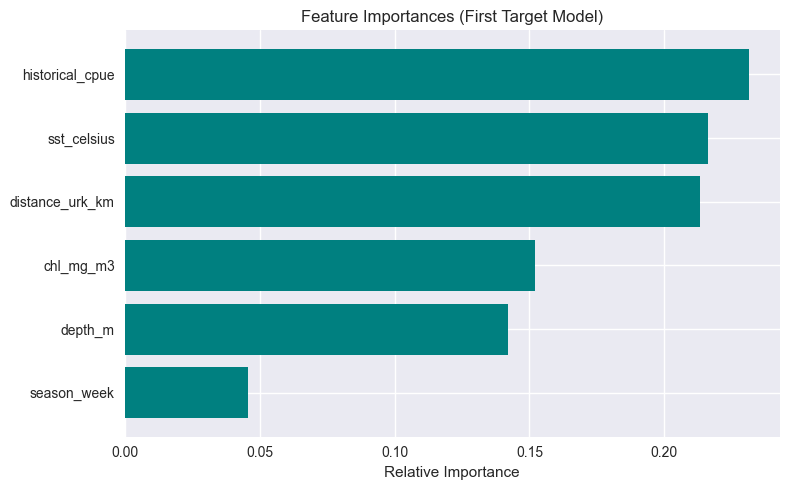

Saved model to: data\bluevantage_model.pkl


In [26]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "sst_celsius", "chl_mg_m3", "depth_m",
    "season_week", "distance_urk_km", "historical_cpue",
]
targets = ["plaice_kg", "sole_kg", "cod_kg", "herring_kg", "mackerel_kg"]

X = df_train[features]
y = df_train[targets]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

base_name = "xgboost"
try:
    import xgboost as xgb
    base_estimator = xgb.XGBRegressor(
        n_estimators=220,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=SEED,
)
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    base_name = "random_forest"
    base_estimator = RandomForestRegressor(
        n_estimators=240,
        max_depth=12,
        random_state=SEED,
        n_jobs=-1,
)

model = MultiOutputRegressor(base_estimator)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results = []
for i, species in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    results.append({"Species": species, "MAE": round(mae, 4), "R2": round(r2, 4)})

df_results = pd.DataFrame(results)
print(f"Model type: {base_name}")
print("Model Evaluation Results:")
print("-" * 40)
print(df_results.to_string(index=False))
print("-" * 40)

if hasattr(model.estimators_[0], "feature_importances_"):
    importances = model.estimators_[0].feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 5))
    plt.title("Feature Importances (First Target Model)")
    plt.barh(range(len(indices)), importances[indices], align="center", color="teal")
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.tight_layout()
    plt.show()

model_path = DATA_DIR / "bluevantage_model.pkl"
joblib.dump(model, model_path)
print(f"Saved model to: {model_path}")

## Step 9: Run Inference and Generate zones.json

In [27]:
import json
import joblib

model = joblib.load(DATA_DIR / "bluevantage_model.pkl")
feature_cols = ["sst_celsius", "chl_mg_m3", "depth_m", "season_week", "distance_urk_km", "historical_cpue"]
preds = model.predict(df_hex_features[feature_cols])

df_hex_features = df_hex_features.copy()
df_hex_features["pred_plaice_kg"] = np.clip(preds[:, 0], a_min=0, a_max=None)
df_hex_features["pred_sole_kg"] = np.clip(preds[:, 1], a_min=0, a_max=None)
df_hex_features["pred_cod_kg"] = np.clip(preds[:, 2], a_min=0, a_max=None)
df_hex_features["pred_herring_kg"] = np.clip(preds[:, 3], a_min=0, a_max=None)
df_hex_features["pred_mackerel_kg"] = np.clip(preds[:, 4], a_min=0, a_max=None)

species_pred_cols = ["pred_plaice_kg", "pred_sole_kg", "pred_cod_kg", "pred_herring_kg", "pred_mackerel_kg"]
df_hex_features["total_pred_kg"] = df_hex_features[species_pred_cols].sum(axis=1)
safe_total = df_hex_features["total_pred_kg"].replace(0, 1e-9)

df_hex_features["p_plaice"] = df_hex_features["pred_plaice_kg"] / safe_total
df_hex_features["p_sole"] = df_hex_features["pred_sole_kg"] / safe_total
df_hex_features["p_cod"] = df_hex_features["pred_cod_kg"] / safe_total
df_hex_features["p_herring"] = df_hex_features["pred_herring_kg"] / safe_total
df_hex_features["p_mackerel"] = df_hex_features["pred_mackerel_kg"] / safe_total

max_pred_plaice = max(float(df_hex_features["pred_plaice_kg"].max()), 1e-9)
max_dist = max(float(df_hex_features["distance_urk_km"].max()), 1e-9)
wave_height = 1.5
wave_factor = max(0.0, 1 - wave_height / 4.0)

df_hex_features["zone_score"] = (
    0.35 * df_hex_features["p_plaice"]
    + 0.25 * (df_hex_features["pred_plaice_kg"] / max_pred_plaice)
    + 0.20 * wave_factor
    + 0.15 * df_hex_features["historical_cpue"]
    - 0.05 * (df_hex_features["distance_urk_km"] / max_dist)
) * 100

df_hex_features["zone_score"] = df_hex_features["zone_score"].round(1)
df_hex_features.loc[df_hex_features["is_mpa"] == True, "zone_score"] = 0

rng = np.random.default_rng(SEED)
df_hex_features["slots_total"] = 5
df_hex_features["slots_filled"] = rng.integers(0, 4, size=len(df_hex_features))

df_hex_features["yield_low_kg"] = df_hex_features["pred_plaice_kg"] * 0.75
df_hex_features["yield_high_kg"] = df_hex_features["pred_plaice_kg"] * 1.25

zones_list = []
for _, row in df_hex_features.iterrows():
    zones_list.append({
        "hex_id": str(row["hex_id"]),
        "lat": float(row["lat"]),
        "lng": float(row["lon"]),
        "zone_score": float(row["zone_score"]),
        "species": [
            {"name": "Plaice", "prob": float(row["p_plaice"])},
            {"name": "Sole", "prob": float(row["p_sole"])},
            {"name": "Cod", "prob": float(row["p_cod"])},
            {"name": "Herring", "prob": float(row["p_herring"])},
            {"name": "Mackerel", "prob": float(row["p_mackerel"])},
        ],
        "yield_low_kg": float(row["yield_low_kg"]),
        "yield_high_kg": float(row["yield_high_kg"]),
        "slots_total": int(row["slots_total"]),
        "slots_filled": int(row["slots_filled"]),
        "wave_height_m": 1.5,
        "wind_kmh": 18,
        "is_mpa": bool(row["is_mpa"]),
        "distance_km": float(row["distance_urk_km"]),
    })

zones_list.sort(key=lambda x: x["zone_score"], reverse=True)

zones_path = DATA_DIR / "zones.json"
with open(zones_path, "w", encoding="utf-8") as f:
    json.dump(zones_list, f, indent=2)

mpa_blocked = sum(1 for z in zones_list if z["is_mpa"])
print(f"zones.json saved to: {zones_path}")
print(f"Total zones exported: {len(zones_list)}")
print(f"MPA-blocked zones (score set to 0): {mpa_blocked}")

zones.json saved to: data\zones.json
Total zones exported: 151
MPA-blocked zones (score set to 0): 0


## Step 10: Validate and Visualize zones.json

In [3]:
import json

zones_path = DATA_DIR / "zones.json"
with open(zones_path, "r", encoding="utf-8") as f:
    zones_data = json.load(f)

df_zones = pd.DataFrame(zones_data)
df_zones["dominant_species"] = df_zones["species"].apply(lambda x: max(x, key=lambda d: d["prob"])["name"])
df_zones["total_pred_kg"] = (df_zones["yield_low_kg"] + df_zones["yield_high_kg"]) / 2

species_names = ["Plaice", "Sole", "Cod", "Herring", "Mackerel"]
for sp in species_names:
    df_zones[f"{sp}_kg"] = df_zones["species"].apply(
        lambda x: next((d["prob"] for d in x if d["name"] == sp), 0.0)
    ) * df_zones["total_pred_kg"]

df_non_mpa = df_zones[~df_zones["is_mpa"]].copy()
df_mpa = df_zones[df_zones["is_mpa"]].copy()

print(f"Total zones: {len(df_zones)}")
print(f"MPA zones (is_mpa=True): {len(df_mpa)}")
if not df_non_mpa.empty:
    print(
        f"Non-MPA Zone Scores -> Min: {df_non_mpa['zone_score'].min():.1f}, "
        f"Max: {df_non_mpa['zone_score'].max():.1f}, "
        f"Mean: {df_non_mpa['zone_score'].mean():.1f}\n"
    )

print("Top 5 Zones by Zone Score:")
print(df_non_mpa.nlargest(5, "zone_score")[["hex_id", "zone_score", "dominant_species"]].to_string(index=False))

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_non_mpa["lng"],
    df_non_mpa["lat"],
    c=df_non_mpa["zone_score"],
    cmap="RdYlGn",
    s=45,
    edgecolors="black",
    linewidth=0.4,
    zorder=2,
    alpha=0.9,
 )
plt.colorbar(sc, label="Zone Score")

if not df_mpa.empty:
    plt.scatter(df_mpa["lng"], df_mpa["lat"], c="red", marker="x", s=45, label="MPA", zorder=3)
    plt.legend()

plt.title("BlueVantage - North Sea Zone Scores")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.5, zorder=1)
plt.show()

plt.figure(figsize=(8, 5))
avg_kg = df_non_mpa[[f"{sp}_kg" for sp in species_names]].mean()
avg_kg.index = species_names
avg_kg.plot(kind="bar", color="teal", edgecolor="black", zorder=2)
plt.title("Average Predicted Catch (kg) per Species (Non-MPA Zones)")
plt.ylabel("Average kg")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7, zorder=1)
plt.tight_layout()
plt.show()

NameError: name 'DATA_DIR' is not defined

In [2]:
%pip install -q supabase
import os
import sys
import subprocess
from pathlib import Path
from supabase import create_client, Client


def load_env_file(env_file: Path) -> bool:
    if not env_file.exists():
        return False

    for raw_line in env_file.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
    return True


dotenv_candidates = [Path.cwd() / ".env", Path.cwd() / "model" / ".env"]
for dotenv_path in dotenv_candidates:
    if load_env_file(dotenv_path):
        break

# Initialize Supabase client
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")
if not SUPABASE_URL or not SUPABASE_KEY:
    raise RuntimeError("Missing Supabase credentials. Create model/.env with SUPABASE_URL and SUPABASE_KEY.")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

success_zones = 0
success_species = 0
errors = []

for zone in zones_data:  # zones_data is already loaded in the previous cell
    # 1. Insert zone (excluding the 'species' list)
    zone_payload = {k: v for k, v in zone.items() if k != "species"}
    
    try:
        supabase.table("zones").insert(zone_payload).execute()
        success_zones += 1
        
        # 2. Insert zone species
        species_payload = [
            {
                "hex_id": zone["hex_id"],
                "species_name": sp["name"],
                "probability": sp["prob"]
            }
            for sp in zone.get("species", [])
        ]
        
        if species_payload:
            supabase.table("zone_species").insert(species_payload).execute()
            success_species += len(species_payload)
            
    except Exception as e:
        errors.append(f"Error inserting zone {zone.get('hex_id')}: {e}")

print(f"Successfully inserted {success_zones} zones and {success_species} species records.")
if errors:
    print(f"Encountered {len(errors)} errors. Showing first 5:")
    for err in errors[:5]:
        print(err)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


NameError: name 'zones_data' is not defined